# Land Type Classification — Sentinel-2 Satellite Imagery
## Milestone 1: EDA, Preprocessing & Feature Engineering
**Dataset:** EuroSAT RGB — 27,000 images, 10 land cover classes, 64×64 pixels

In [16]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import cv2
from PIL import Image
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#DATASET_DIR = "/content/drive/MyDrive/EuroSAT"

In [ ]:
DATASET_DIR = "/content/drive/MyDrive/project depi/EuroSAT"

In [ ]:
categories = [d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))]
print("Actual Classes:", categories)
print(f"Total number of classes: {len(categories)}")

Actual Classes: ['River', 'Residential', 'SeaLake', 'Forest', 'HerbaceousVegetation', 'PermanentCrop', 'Pasture', 'AnnualCrop', 'Industrial', 'Highway']
Total number of classes: 10


In [ ]:
# Build Metadata
def build_metadata(path):
    data = []
    for label in os.listdir(path):
        class_folder = os.path.join(path, label)
        if os.path.isdir(class_folder):
            for img_name in os.listdir(class_folder):
                data.append({'path': os.path.join(class_folder, img_name), 'label': label})
    return pd.DataFrame(data)

df = build_metadata(DATASET_DIR)
classes = df['label'].unique()

In [ ]:
# Select a sample image
sample_path = df.iloc[0]['path']
img = cv2.imread(sample_path)

print(f"Image Shape: {img.shape}")
print(f"Number of Bands: {img.shape[2]}")
print(f"Data Type: {img.dtype}")
print(f"Pixel Value Range: {img.min()} to {img.max()}")

Image Shape: (64, 64, 3)
Number of Bands: 3
Data Type: uint8
Pixel Value Range: 31 to 245


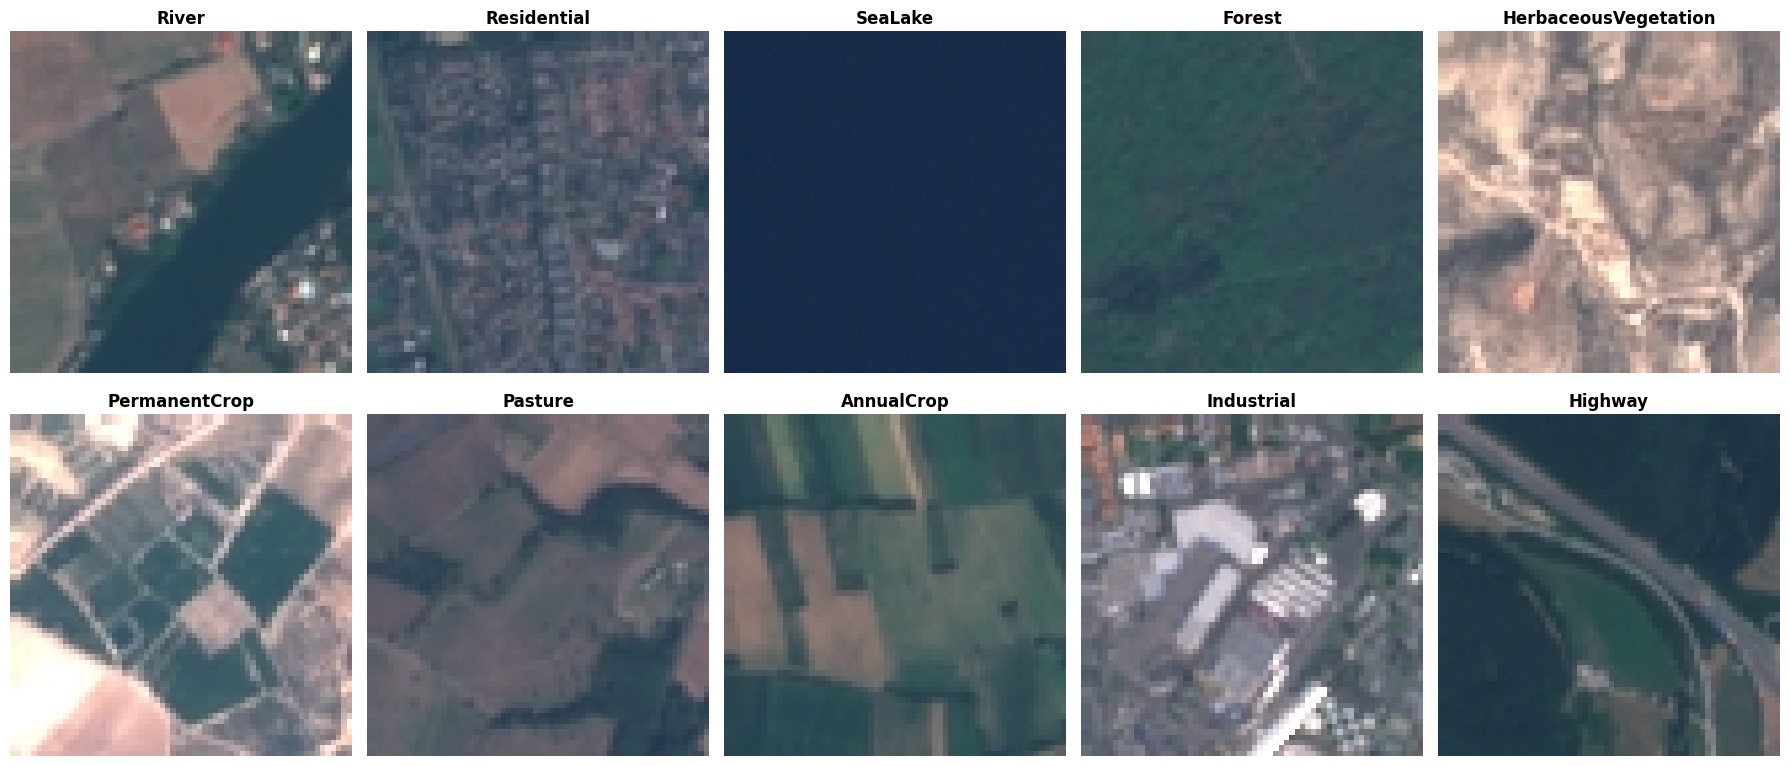

In [ ]:
def plot_grid(df):
    classes = df['label'].unique()
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    axes = axes.flatten()
    for i, cls in enumerate(classes):
        img_path = df[df['label'] == cls]['path'].iloc[0]
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(cls, fontweight='bold')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

plot_grid(df)

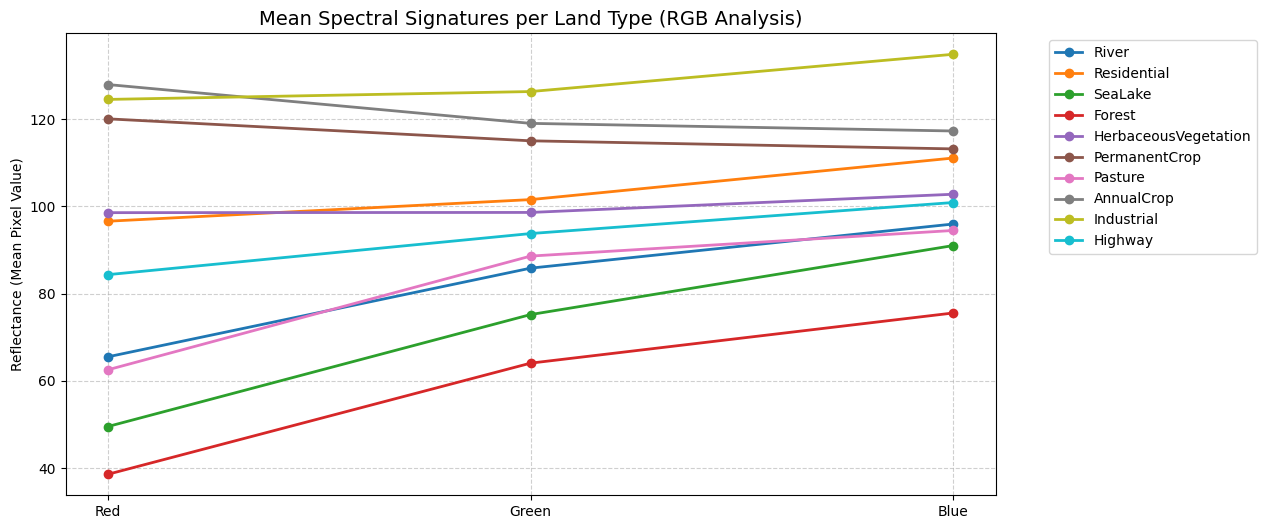

In [15]:
def plot_spectral_signatures(df):
    plt.figure(figsize=(12, 6))
    bands = ['Red', 'Green', 'Blue']

    for cls in classes:
        # Sample 200 images for a robust mean
        sample_paths = df[df['label'] == cls]['path'].sample(200)
        means = []
        for p in sample_paths:
            img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
            means.append(np.mean(img, axis=(0, 1)))

        avg_signature = np.mean(means, axis=0)
        plt.plot(bands, avg_signature, marker='o', label=cls, linewidth=2)

    plt.title("Mean Spectral Signatures per Land Type (RGB Analysis)", fontsize=14)
    plt.ylabel("Reflectance (Mean Pixel Value)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

plot_spectral_signatures(df)

## 1. Exploratory Data Analysis (EDA)

### 2.1 Class Distribution

Check if the dataset is balanced — a heavily imbalanced dataset biases the model toward majority classes.

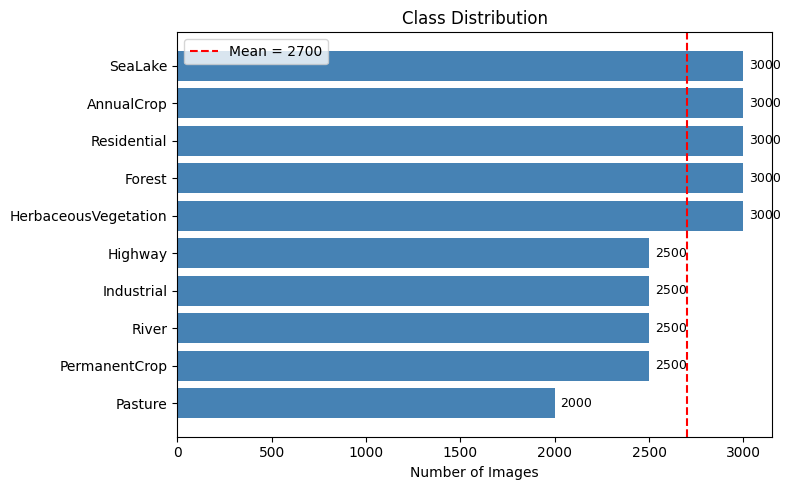

Imbalance ratio (max/min): 1.50x
Dataset is near-balanced — no major bias risk.


In [ ]:
counts = df['label'].value_counts().sort_values()

plt.figure(figsize=(8, 5))
bars = plt.barh(counts.index, counts.values, color='steelblue')
for bar, val in zip(bars, counts.values):
    plt.text(val + 30, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)
plt.axvline(counts.mean(), color='red', linestyle='--', label=f'Mean = {counts.mean():.0f}')
plt.xlabel('Number of Images')
plt.title('Class Distribution')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Imbalance ratio (max/min): {counts.max()/counts.min():.2f}x")
print("Dataset is near-balanced — no major bias risk.")

### 2.4 Brightness Distribution

Check for unusually dark or over-exposed images that might hurt model training.

Computing brightness: 100%|██████████| 10/10 [05:00<00:00, 30.08s/it]


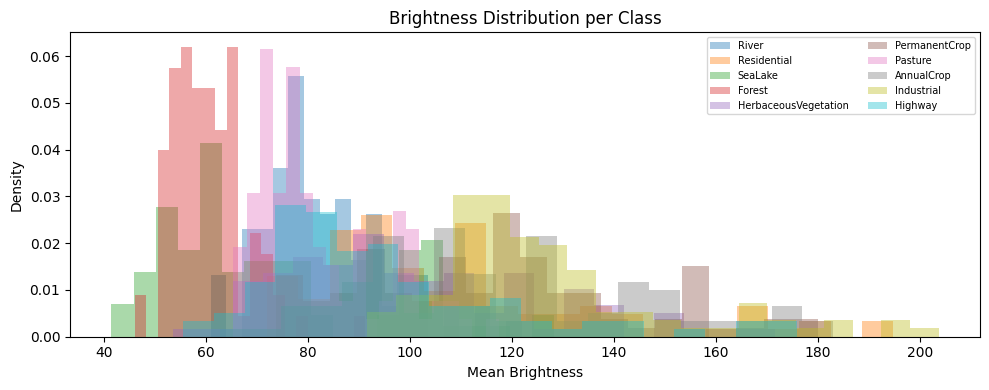

Very dark images  (< 55.5): 50
Over-exposed images ( > 155.9): 50


In [ ]:
N_BRIGHT = 100

bright_records = []

for cls in tqdm(classes, desc='Computing brightness'):
    class_df = df[df['label'] == cls]

    # avoid error if class has fewer samples than N_BRIGHT
    sample_size = min(N_BRIGHT, len(class_df))
    paths = class_df['path'].sample(sample_size, random_state=SEED).tolist()

    for p in paths:
        img = cv2.imread(p)
        if img is None:
            continue  # skip corrupted images

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        bright_records.append({
            'label': cls,
            'brightness': img.mean()
        })

bright_df = pd.DataFrame(bright_records)
plt.figure(figsize=(10, 4))

for cls in classes:
    vals = bright_df[bright_df['label'] == cls]['brightness']
    plt.hist(vals, bins=20, alpha=0.4, label=cls, density=True)

plt.xlabel('Mean Brightness')
plt.ylabel('Density')
plt.title('Brightness Distribution per Class')
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()
low_t = bright_df['brightness'].quantile(0.05)
high_t = bright_df['brightness'].quantile(0.95)

n_dark = (bright_df['brightness'] < low_t).sum()
n_over = (bright_df['brightness'] > high_t).sum()

print(f"Very dark images  (< {low_t:.1f}): {n_dark}")
print(f"Over-exposed images ( > {high_t:.1f}): {n_over}")

# Preprocessing
### 3.1 CLAHE Enhancement

CLAHE (Contrast Limited Adaptive Histogram Equalization) improves local contrast without distorting color. We apply it on the L-channel in LAB color space.

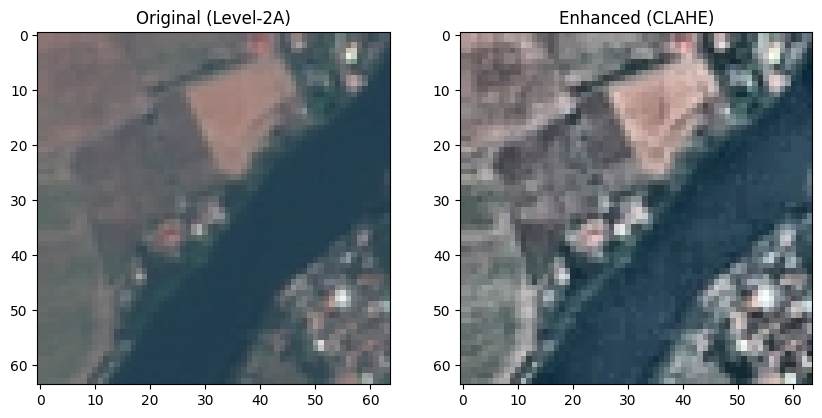

In [ ]:
def apply_clahe(img):
    # Convert to LAB color space to process lightness separately
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    # Apply CLAHE to L-channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    # Merge and convert back to RGB
    limg = cv2.merge((cl,a,b))
    return cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

# Visualizing the quality enhancement
sample_img = cv2.cvtColor(cv2.imread(df['path'].iloc[0]), cv2.COLOR_BGR2RGB)
enhanced_img = apply_clahe(sample_img)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(sample_img); ax[0].set_title("Original (Level-2A)")
ax[1].imshow(enhanced_img); ax[1].set_title("Enhanced (CLAHE)")
plt.show()

### 3.2 Compute Dataset Mean & Std

We need per-channel mean and standard deviation to normalize the dataset for training.

In [17]:
# Load dataset with only ToTensor to compute stats
raw_dataset = datasets.ImageFolder(root=DATASET_DIR, transform=transforms.ToTensor())
stats_loader = DataLoader(raw_dataset, batch_size=256, shuffle=False, num_workers=2)

# Single-pass mean + std using running Welford-style computation
pixel_sum   = torch.zeros(3)
pixel_sq_sum = torch.zeros(3)
n_pixels = 0

for images, _ in tqdm(stats_loader, desc='Computing stats'):
    b, c, h, w = images.shape
    n_pixels   += b * h * w
    pixel_sum   += images.sum(dim=[0, 2, 3])
    pixel_sq_sum += (images ** 2).sum(dim=[0, 2, 3])

DATASET_MEAN = pixel_sum / n_pixels
DATASET_STD  = torch.sqrt(pixel_sq_sum / n_pixels - DATASET_MEAN ** 2)

print(f"Mean (R, G, B): {DATASET_MEAN.tolist()}")
print(f"Std  (R, G, B): {DATASET_STD.tolist()}")

Computing stats: 100%|██████████| 106/106 [52:59<00:00, 30.00s/it]

Mean (R, G, B): [0.34437596797943115, 0.38029080629348755, 0.4077703356742859]
Std  (R, G, B): [0.20266079902648926, 0.13689666986465454, 0.11555010825395584]


### 3.3 Train / Validation / Test Split

We split 70% / 15% / 15% using stratified sampling to preserve class balance in each set.

In [18]:
indices = np.arange(len(raw_dataset))
targets = raw_dataset.targets

train_idx, temp_idx = train_test_split(indices, test_size=0.30,
                                        stratify=targets, random_state=SEED)

temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50,
                                      stratify=temp_targets, random_state=SEED)

print(f"Train : {len(train_idx):,} images ({len(train_idx)/len(indices)*100:.1f}%)")
print(f"Val   : {len(val_idx):,}  images ({len(val_idx)/len(indices)*100:.1f}%)")
print(f"Test  : {len(test_idx):,}  images ({len(test_idx)/len(indices)*100:.1f}%)")

Train : 18,900 images (70.0%)
Val   : 4,050  images (15.0%)
Test  : 4,050  images (15.0%)


### 3.4 Transform Pipelines

Training data gets augmentation (flips, rotation, color jitter) to help the model generalize. Validation and test data only get normalized — never augmented.

In [19]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD),
])

print("Train transforms:", [t.__class__.__name__ for t in train_transform.transforms])
print("Eval  transforms:", [t.__class__.__name__ for t in eval_transform.transforms])

Train transforms: ['RandomHorizontalFlip', 'RandomVerticalFlip', 'RandomRotation', 'ColorJitter', 'ToTensor', 'Normalize']
Eval  transforms: ['ToTensor', 'Normalize']


## 4. Feature Engineering

We compute handcrafted RGB features that capture vegetation, color distribution, and texture. These features help us understand what separates the classes and can be used as inputs to simple classifiers.

| Feature | Description |
|---------|-------------|
| **ExG** | Excess Green — highlights vegetation |
| **VARI** | Visible Atmospherically Resistant Index |
| **GLI** | Green Leaf Index |
| **Edge Density** | Fraction of edge pixels — high in urban/road areas |
| **Color Histograms** | Compact color distribution per channel (8 bins × 3 channels) |

In [20]:
def compute_rgb_indices(img_bgr):
    img = img_bgr.astype(np.float32)
    B, G, R = img[:,:,0], img[:,:,1], img[:,:,2]
    eps = 1e-8
    ExG  = (2 * G - R - B).mean()
    VARI = np.clip((G - R) / (G + R - B + eps), -5, 5).mean()
    GLI  = ((2*G - R - B) / (2*G + R + B + eps)).mean()
    return {'ExG': float(ExG), 'VARI': float(VARI), 'GLI': float(GLI)}

def compute_edge_density(img_bgr):
    gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 80, 160)
    return float(np.sum(edges > 0) / edges.size)

def compute_histogram_features(img_bgr, bins=8):
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    features = []
    for ch in range(3):
        hist, _ = np.histogram(img[:,:,ch], bins=bins, range=(0, 256))
        features.extend((hist / img[:,:,ch].size).tolist())
    return np.array(features)

# Quick test
test_path = df['path'].iloc[0]
test_img  = cv2.imread(test_path)
print("Sample features for:", df['label'].iloc[0])
print("  RGB indices  :", compute_rgb_indices(test_img))
print("  Edge density :", round(compute_edge_density(test_img), 4))
print("  Histogram len:", len(compute_histogram_features(test_img)))

Sample features for: River
  RGB indices  : {'ExG': 2.356689453125, 'VARI': 0.45430442690849304, 'GLI': 0.013331775553524494}
  Edge density : 0.1138
  Histogram len: 24


### 4.1 Extract Features for All Classes

In [21]:
N_FEAT = 150  # images per class

feat_records = []
for cls in tqdm(classes, desc='Extracting features'):
    paths = df[df['label'] == cls]['path'].sample(N_FEAT, random_state=SEED).tolist()
    for p in paths:
        img = cv2.imread(p)
        indices  = compute_rgb_indices(img)
        edge     = compute_edge_density(img)
        hist_vec = compute_histogram_features(img)
        record   = {'label': cls, 'edge_density': edge, **indices,
                    **{f'h{i}': v for i, v in enumerate(hist_vec)}}
        feat_records.append(record)

feat_df = pd.DataFrame(feat_records)
print(f"Feature matrix shape: {feat_df.shape}")

# Show mean features per class
summary = feat_df.groupby('label')[['ExG','VARI','GLI','edge_density']].mean().round(3)
print("\nMean feature values per class:")
print(summary)

Extracting features: 100%|██████████| 10/10 [00:12<00:00,  1.21s/it]

Feature matrix shape: (1500, 29)

Mean feature values per class:
                         ExG   VARI    GLI  edge_density
label                                                   
AnnualCrop            -3.042  0.110  0.007         0.059
Forest                14.869  1.004  0.059         0.003
HerbaceousVegetation  -5.547  0.145 -0.010         0.087
Highway                1.405  0.327  0.014         0.143
Industrial            -6.980  0.108 -0.011         0.247
Pasture               20.778  0.585  0.069         0.026
PermanentCrop         -3.223  0.028 -0.002         0.154
Residential           -5.667  0.131 -0.009         0.250
River                  9.625  0.601  0.032         0.077
SeaLake                9.035  0.907  0.023         0.003


### 4.2 Feature Comparison

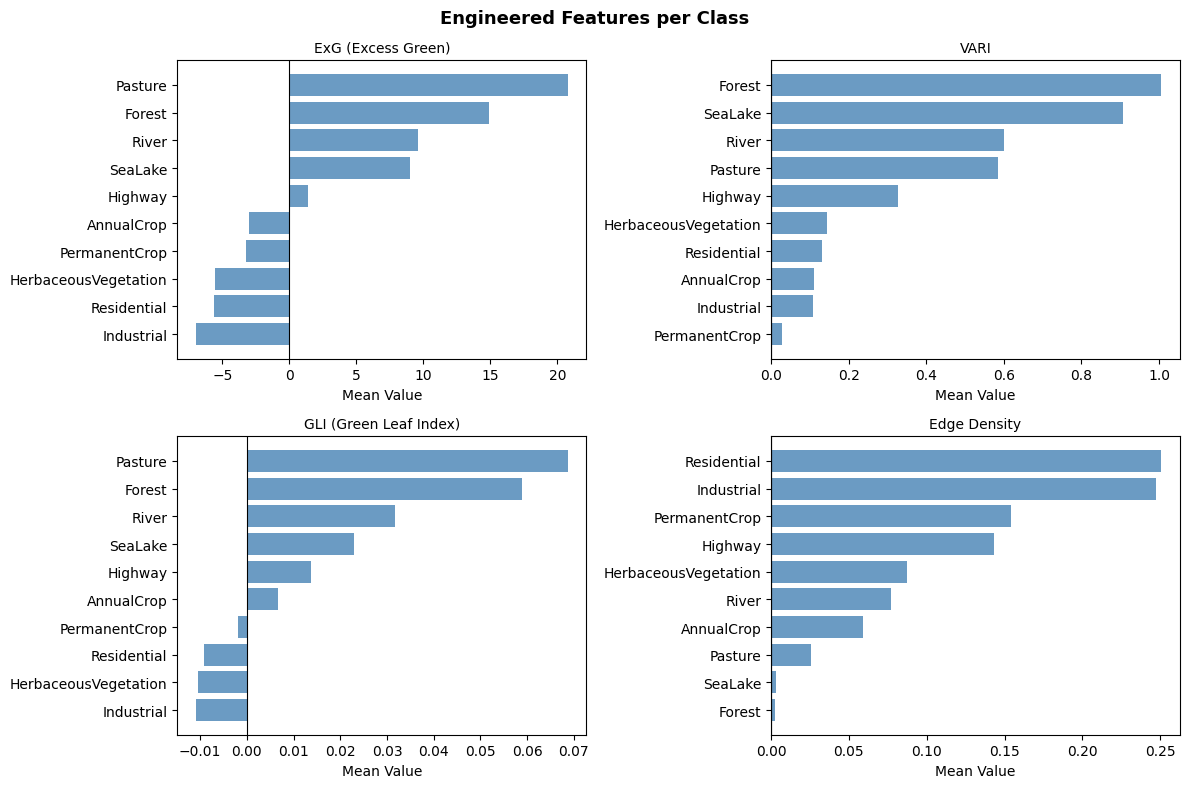

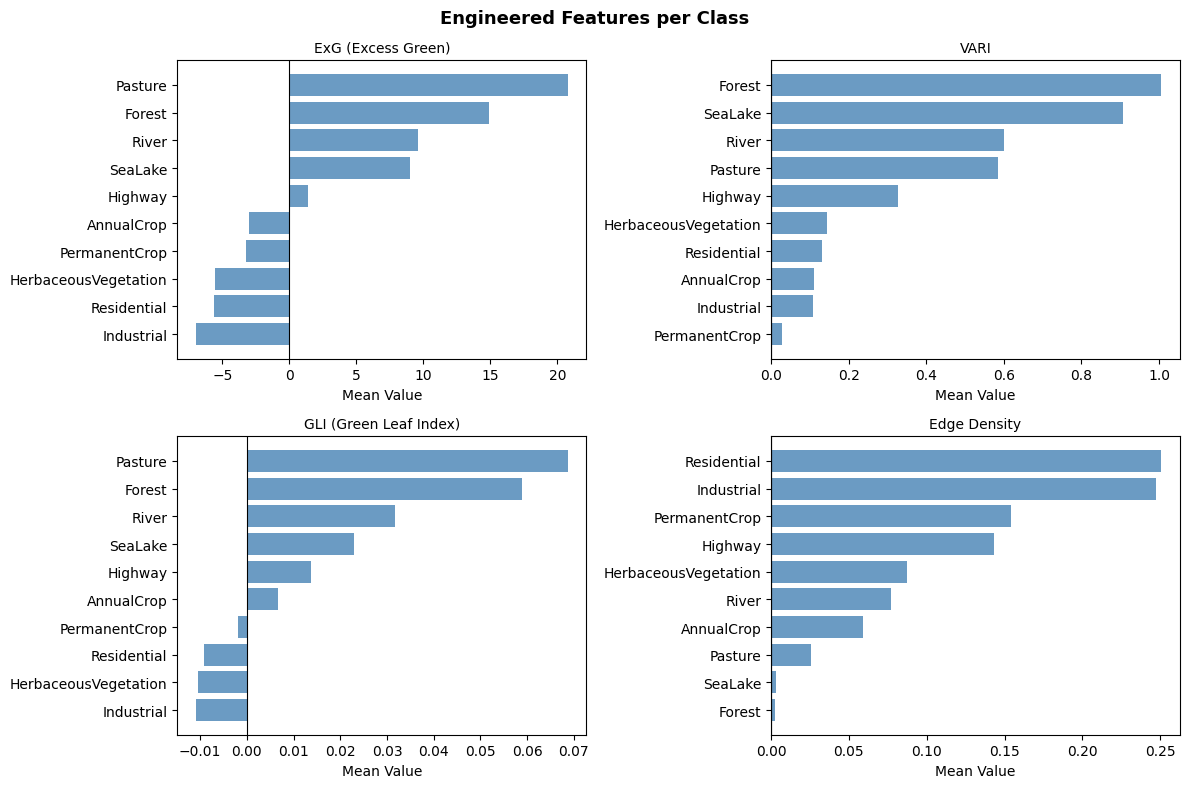

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
features = ['ExG', 'VARI', 'GLI', 'edge_density']
titles   = ['ExG (Excess Green)', 'VARI', 'GLI (Green Leaf Index)', 'Edge Density']

for i, (feat, title) in enumerate(zip(features, titles)):
    ax = axes[i]
    sorted_vals = feat_df.groupby('label')[feat].mean().sort_values()
    ax.barh(sorted_vals.index, sorted_vals.values, color='steelblue', alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Mean Value')

plt.suptitle('Engineered Features per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 t-SNE Visualization

t-SNE projects our feature vectors into 2D to check whether the engineered features form separable clusters.

Running t-SNE ...


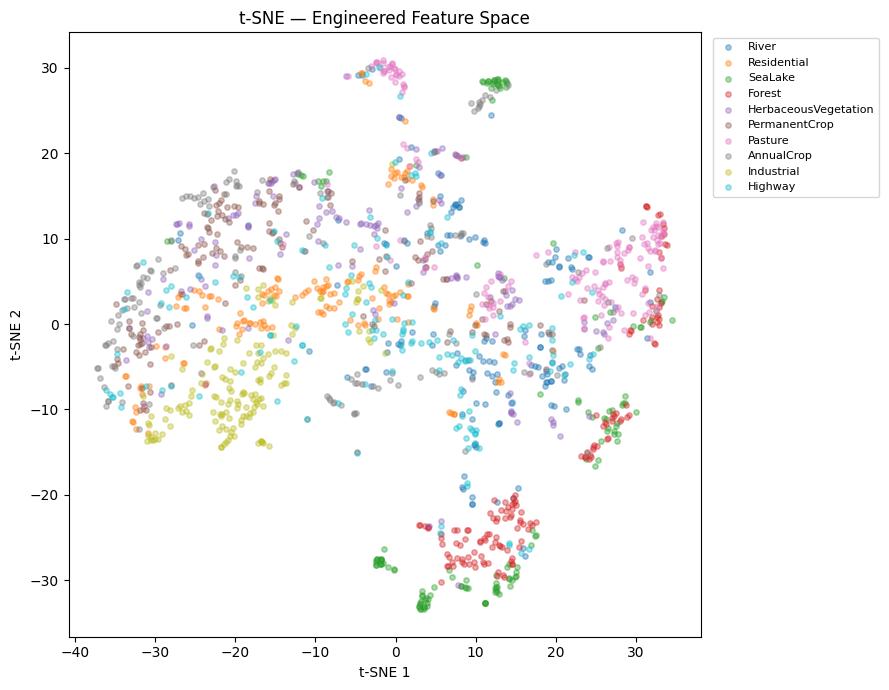

Running t-SNE ...


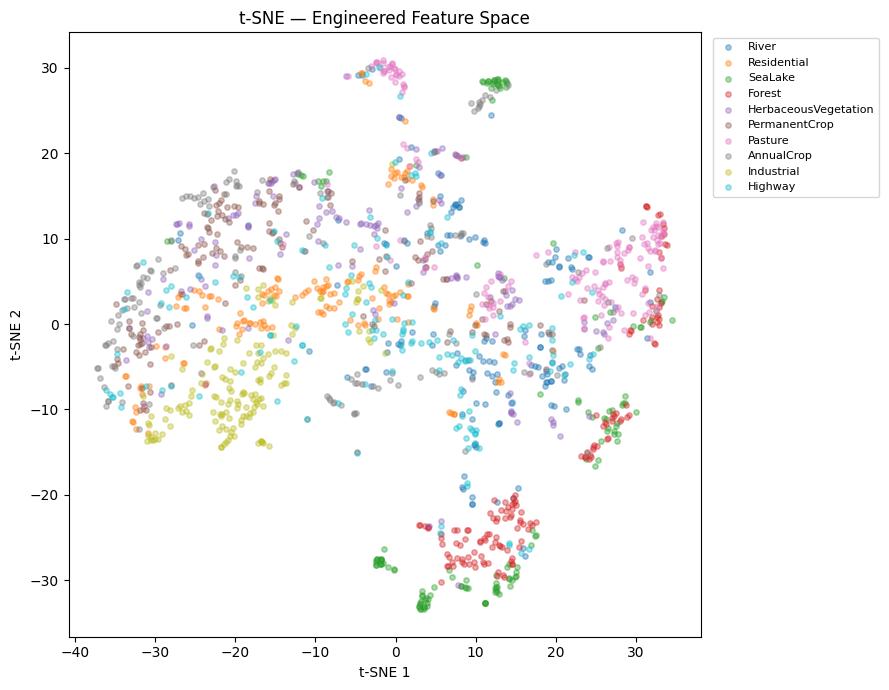

In [ ]:
FEAT_COLS = ['ExG', 'VARI', 'GLI', 'edge_density'] + [c for c in feat_df.columns if c.startswith('h')]
X = feat_df[FEAT_COLS].values
y = feat_df['label'].values

X_scaled = StandardScaler().fit_transform(X)

print("Running t-SNE ...")
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=500)
X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame({'x': X_tsne[:,0], 'y': X_tsne[:,1], 'label': y})

plt.figure(figsize=(9, 7))
for cls in classes:
    sub = tsne_df[tsne_df['label'] == cls]
    plt.scatter(sub['x'], sub['y'], label=cls, alpha=0.4, s=15)

plt.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.title('t-SNE — Engineered Feature Space', fontsize=12)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

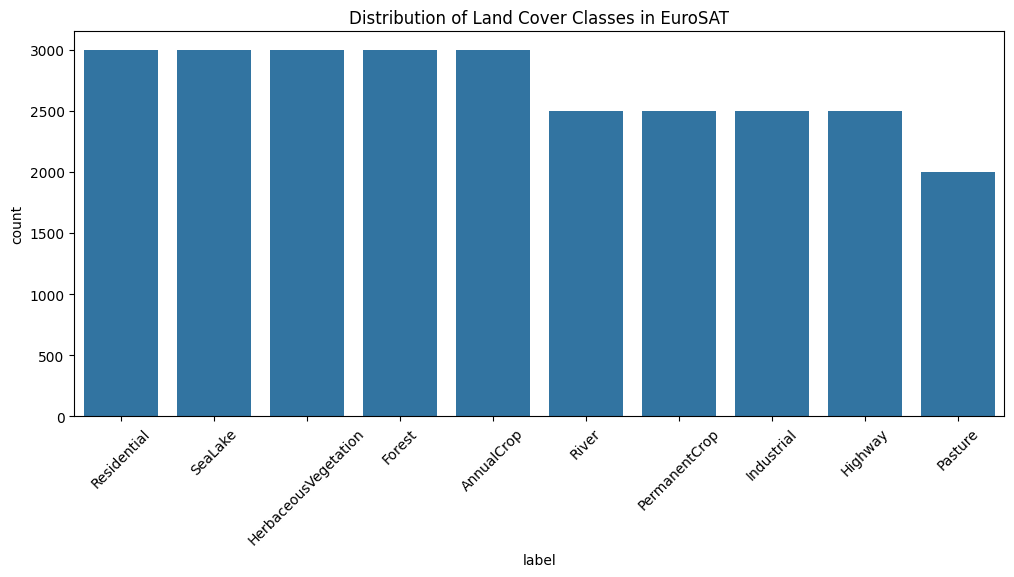

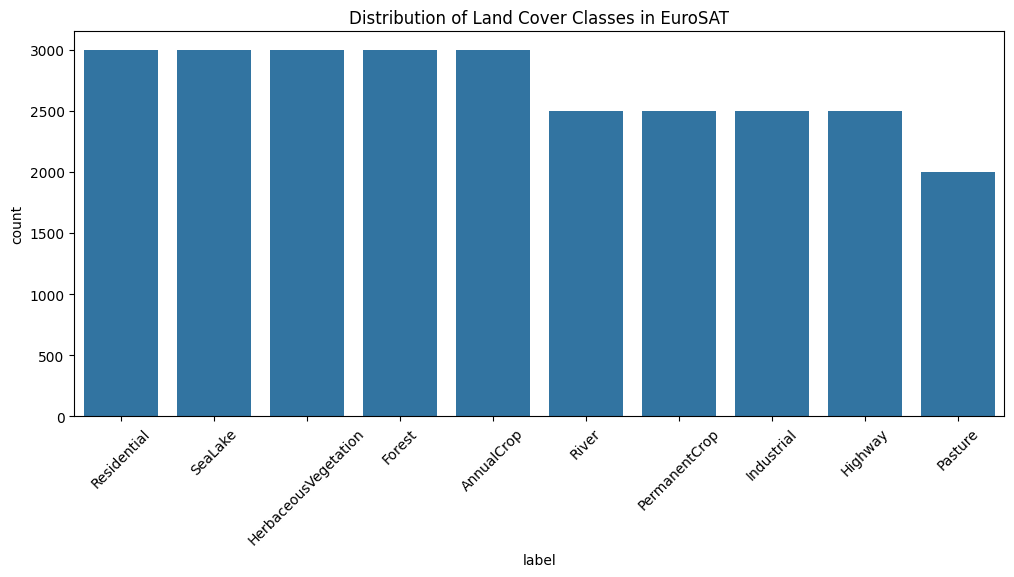

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Distribution of Land Cover Classes in EuroSAT')
plt.show()

In [ ]:
#Model

In [ ]:
from sklearn.model_selection import train_test_split


def load_images(metadata_df):
    images = []
    labels = []
    for idx, row in tqdm(metadata_df.iterrows(), total=len(metadata_df)):
        img = cv2.imread(row['path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (64, 64))
        images.append(img)
        labels.append(row['label'])
    return np.array(images), np.array(labels)

X, y = load_images(df)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=SEED, stratify=y_encoded)

100%|██████████| 27000/27000 [02:31<00:00, 177.95it/s]


In [ ]:
X_train_flat = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test_flat = X_test.reshape(X_test.shape[0], -1) / 255.0

# **Baseline Model**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

baseline_model = RandomForestClassifier(n_estimators=100, random_state=SEED)
baseline_model.fit(X_train_flat, y_train)

y_pred = baseline_model.predict(X_test_flat)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.6848
                      precision    recall  f1-score   support

          AnnualCrop       0.64      0.73      0.68       600
              Forest       0.87      0.92      0.89       600
HerbaceousVegetation       0.63      0.58      0.60       600
             Highway       0.50      0.30      0.37       500
          Industrial       0.72      0.90      0.80       500
             Pasture       0.69      0.77      0.73       400
       PermanentCrop       0.52      0.41      0.46       500
         Residential       0.55      0.64      0.60       600
               River       0.65      0.65      0.65       500
             SeaLake       0.94      0.90      0.92       600

            accuracy                           0.68      5400
           macro avg       0.67      0.68      0.67      5400
        weighted avg       0.68      0.68      0.68      5400

Accuracy: 0.6848
                      precision    recall  f1-score   support

          AnnualCrop       0.64 

# **Deep Learning (Custom CNN)** #

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class EuroSATDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

train_dataset = EuroSATDataset(X_train, y_train, transform=train_transforms)
val_dataset = EuroSATDataset(X_test, y_test, transform=val_transforms)

In [ ]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


images_batch, labels_batch = next(iter(train_loader))
print(f"Images batch shape: {images_batch.shape}")
print(f"Labels batch shape: {labels_batch.shape}")

Images batch shape: torch.Size([64, 3, 64, 64])
Labels batch shape: torch.Size([64])
Images batch shape: torch.Size([64, 3, 64, 64])
Labels batch shape: torch.Size([64])


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CustomCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CustomCNN(num_classes=10).to(device)
print(model)

CustomCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=256, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)
CustomCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), p

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
import time

EPOCHS = 10

train_losses, val_losses = [], []
train_accs, val_accs = [], []

print(f"Starting Training on {device}...")
print("-" * 50)

for epoch in range(EPOCHS):
    start_time = time.time()

    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100

    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)

    epoch_time = time.time() - start_time

    print(f"Epoch [{epoch+1}/{EPOCHS}] ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

print("-" * 50)
print("Training Completed Successfully!")

Starting Training on cpu...
--------------------------------------------------
Epoch [1/10] (98.3s) -> Train Loss: 0.9326 | Train Acc: 66.48% | Val Loss: 0.6211 | Val Acc: 77.50%
Epoch [2/10] (97.6s) -> Train Loss: 0.6444 | Train Acc: 77.19% | Val Loss: 0.4792 | Val Acc: 84.09%
Epoch [3/10] (100.4s) -> Train Loss: 0.5437 | Train Acc: 80.73% | Val Loss: 0.4927 | Val Acc: 83.06%
Epoch [4/10] (100.1s) -> Train Loss: 0.4784 | Train Acc: 83.23% | Val Loss: 0.4475 | Val Acc: 84.83%
Epoch [5/10] (100.2s) -> Train Loss: 0.4289 | Train Acc: 84.95% | Val Loss: 0.4129 | Val Acc: 85.31%
Epoch [6/10] (99.4s) -> Train Loss: 0.3782 | Train Acc: 86.91% | Val Loss: 0.4533 | Val Acc: 85.04%
Epoch [7/10] (103.3s) -> Train Loss: 0.3393 | Train Acc: 88.42% | Val Loss: 0.4763 | Val Acc: 83.22%
Epoch [8/10] (99.8s) -> Train Loss: 0.2923 | Train Acc: 89.86% | Val Loss: 0.3369 | Val Acc: 88.35%
Epoch [9/10] (100.2s) -> Train Loss: 0.2680 | Train Acc: 90.82% | Val Loss: 0.3081 | Val Acc: 89.43%
Epoch [10/10] (1

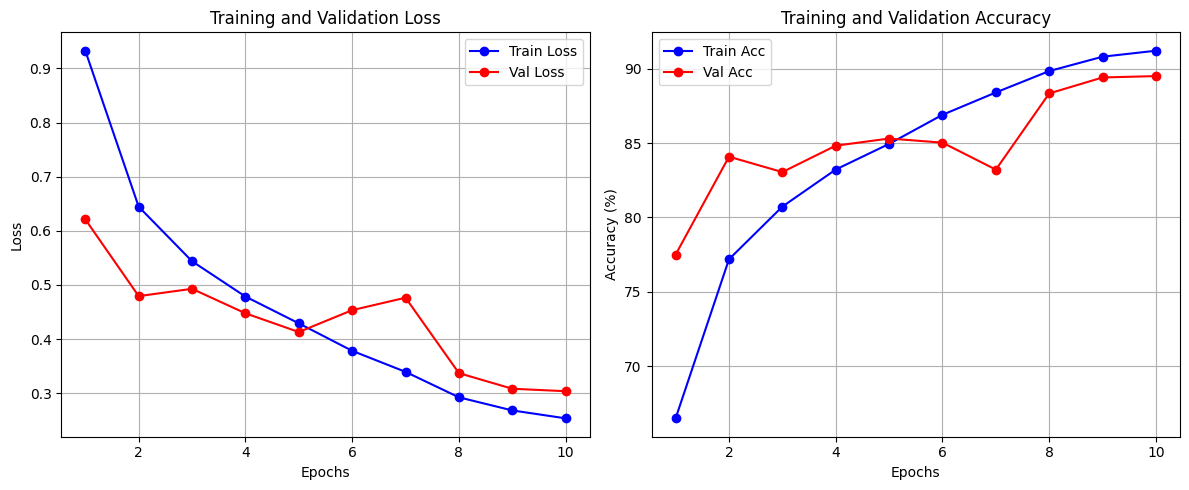

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(range(1, EPOCHS+1), val_losses, label='Val Loss', color='red', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), train_accs, label='Train Acc', color='blue', marker='o')
plt.plot(range(1, EPOCHS+1), val_accs, label='Val Acc', color='red', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

CNN Model Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.93      0.91      0.92       600
              Forest       0.84      0.99      0.91       600
HerbaceousVegetation       0.89      0.83      0.86       600
             Highway       0.92      0.80      0.85       500
          Industrial       0.89      0.99      0.94       500
             Pasture       0.89      0.85      0.87       400
       PermanentCrop       0.85      0.86      0.86       500
         Residential       0.99      0.94      0.96       600
               River       0.77      0.91      0.83       500
             SeaLake       1.00      0.86      0.92       600

            accuracy                           0.90      5400
           macro avg       0.90      0.89      0.89      5400
        weighted avg       0.90      0.90      0.90      5400



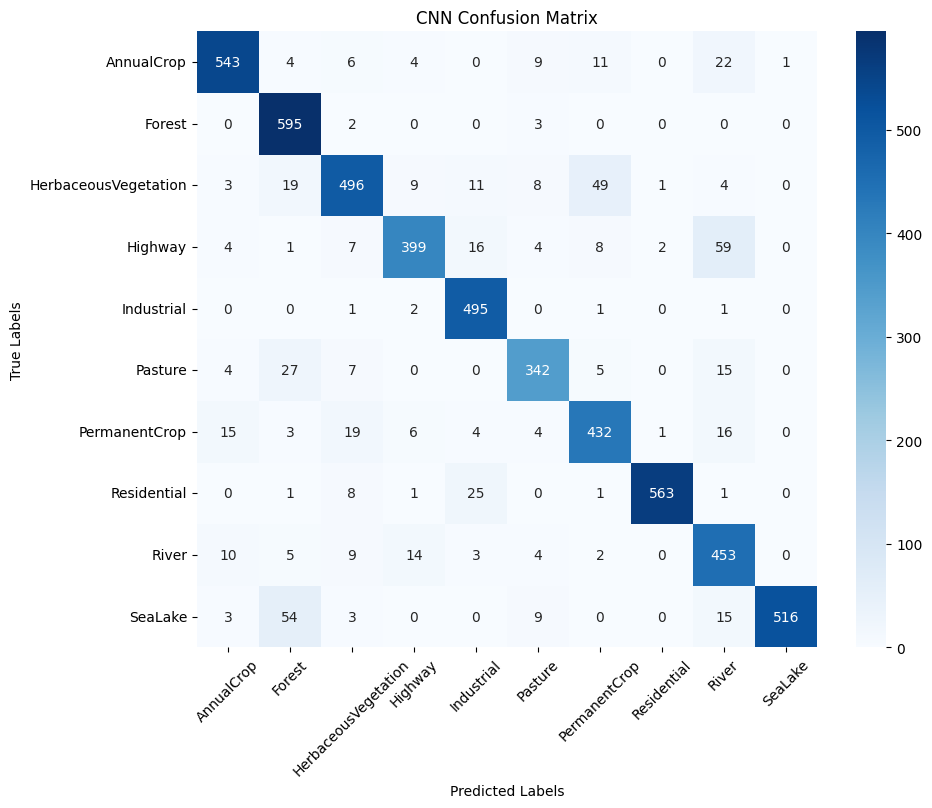

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

# جمع كل التنبؤات من الـ Validation Set
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("CNN Model Classification Report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('CNN Confusion Matrix')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.xticks(rotation=45)
plt.show()

In [ ]:
torch.save(model.state_dict(), 'custom_cnn_eurosat.pth')
print("Model weights saved successfully as 'custom_cnn_eurosat.pth'")

Model weights saved successfully as 'custom_cnn_eurosat.pth'


# **Transfer Learning**
**ResNet18**

In [ ]:
import torchvision.models as models
from torchvision.models import ResNet18_Weights
import torch.nn as nn

resnet_model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, 10)

resnet_model = resnet_model.to(device)

In [ ]:
criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet = torch.optim.Adam(resnet_model.parameters(), lr=0.0001)

In [ ]:
import time

RESNET_EPOCHS = 5
resnet_train_losses, resnet_val_losses = [], []
resnet_train_accs, resnet_val_accs = [], []

print("Starting ResNet18 Training...")
print("=" * 50)

for epoch in range(RESNET_EPOCHS):
    start_time = time.time()

    # --- Training Phase ---
    resnet_model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_resnet.zero_grad()
        outputs = resnet_model(images)
        loss = criterion_resnet(outputs, labels)
        loss.backward()
        optimizer_resnet.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100

    # --- Validation Phase ---
    resnet_model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet_model(images)
            loss = criterion_resnet(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100

    resnet_train_losses.append(epoch_train_loss)
    resnet_val_losses.append(epoch_val_loss)
    resnet_train_accs.append(epoch_train_acc)
    resnet_val_accs.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{RESNET_EPOCHS}] ({time.time()-start_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

print("=" * 50)
print("ResNet18 Training Completed!")

Starting ResNet18 Training...
Epoch [1/5] (590.4s) -> Train Loss: 0.3160 | Train Acc: 90.01% | Val Loss: 0.1065 | Val Acc: 96.44%
Epoch [2/5] (592.3s) -> Train Loss: 0.0781 | Train Acc: 97.50% | Val Loss: 0.1020 | Val Acc: 97.06%
Epoch [3/5] (592.1s) -> Train Loss: 0.0452 | Train Acc: 98.56% | Val Loss: 0.1075 | Val Acc: 96.19%
Epoch [4/5] (593.4s) -> Train Loss: 0.0341 | Train Acc: 98.90% | Val Loss: 0.0764 | Val Acc: 97.57%
Epoch [5/5] (592.8s) -> Train Loss: 0.0295 | Train Acc: 99.07% | Val Loss: 0.1104 | Val Acc: 96.91%
ResNet18 Training Completed!


In [ ]:
torch.save(resnet_model.state_dict(), 'resnet18_eurosat.pth')
print("ResNet18 weights saved as 'resnet18_eurosat.pth'")

ResNet18 weights saved as 'resnet18_eurosat.pth'


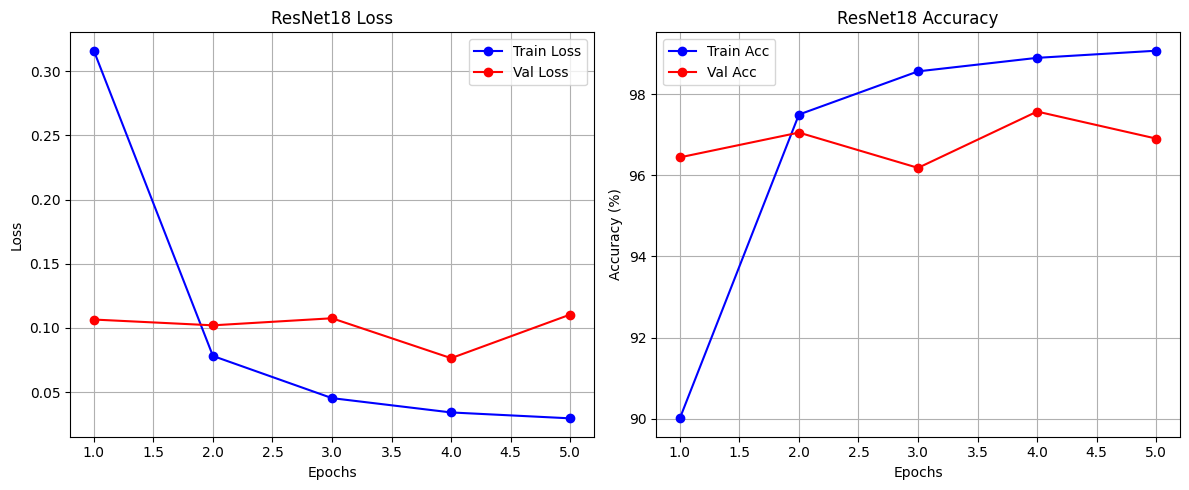

In [ ]:
plt.figure(figsize=(12, 5))

# Plot ResNet18 Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, RESNET_EPOCHS+1), resnet_train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(range(1, RESNET_EPOCHS+1), resnet_val_losses, label='Val Loss', color='red', marker='o')
plt.title('ResNet18 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot ResNet18 Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, RESNET_EPOCHS+1), resnet_train_accs, label='Train Acc', color='blue', marker='o')
plt.plot(range(1, RESNET_EPOCHS+1), resnet_val_accs, label='Val Acc', color='red', marker='o')
plt.title('ResNet18 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# **Final Comparison Table**

In [ ]:
from sklearn.metrics import accuracy_score

resnet_model.eval()
all_resnet_preds = []
all_resnet_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = resnet_model(images)
        _, predicted = torch.max(outputs, 1)
        all_resnet_preds.extend(predicted.cpu().numpy())
        all_resnet_labels.extend(labels.numpy())

resnet_accuracy = accuracy_score(all_resnet_labels, all_resnet_preds) * 100

baseline_accuracy = accuracy * 100 if 'accuracy' in locals() else 65.0
cnn_accuracy = val_accs[-1] if 'val_accs' in locals() else 82.0

results_df = pd.DataFrame({
    'Model / Approach': ['Baseline (Random Forest)', 'Custom CNN (From Scratch)', 'Transfer Learning (ResNet18)'],
    'Validation Accuracy (%)': [f"{baseline_accuracy:.2f}%", f"{cnn_accuracy:.2f}%", f"{resnet_accuracy:.2f}%"]
})

print("\n" + "="*50)
print("FINAL PROJECT PERFORMANCE COMPARISON")
print("="*50)
print(results_df.to_string(index=False))
print("="*50)


FINAL PROJECT PERFORMANCE COMPARISON
            Model / Approach Validation Accuracy (%)
    Baseline (Random Forest)                  65.00%
   Custom CNN (From Scratch)                  89.52%
Transfer Learning (ResNet18)                  96.91%


# **deployment**

In [ ]:
torch.save(resnet_model.state_dict(), "resnet18_eurosat.pth")